Assignment topic - Autoencoder for dimensionality reduction  

Date - 10.03.2026

name - Riddhi

Roll number - CS23B2024

In [ ]:
'''MNIST dataset compression and reconstruction using PCA and AutoEncoder.
Train a PCA model to compress the digits to 4 dimensional latent vectors.
Train an AutoEncoder model to compress the digits to 4 dimensional latent vectors.'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import mean_squared_error

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

#PCA Compression
pca = PCA(n_components=4)
x_train_pca_latent = pca.fit_transform(x_train_flat)
x_test_pca_latent = pca.transform(x_test_flat)
x_test_pca_reconstructed = pca.inverse_transform(x_test_pca_latent).reshape((-1, 28, 28))

#AutoEncoder Compression
input_dim = x_train_flat.shape[1]
latent_dim = 4

#Encoder
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(latent_dim, activation='linear')(encoded)

#Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256, validation_data=(x_test_flat, x_test_flat))


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.1009 - val_loss: 0.0457
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0436 - val_loss: 0.0385
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0381 - val_loss: 0.0357
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0353 - val_loss: 0.0341
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0339 - val_loss: 0.0330
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0328 - val_loss: 0.0322
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0318 - val_loss: 0.0314
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0311 - val_loss: 0.0310
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0307 - val_loss: 0.0307
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0304 - val_loss: 0.0304
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0301 - val_loss: 0.0301
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


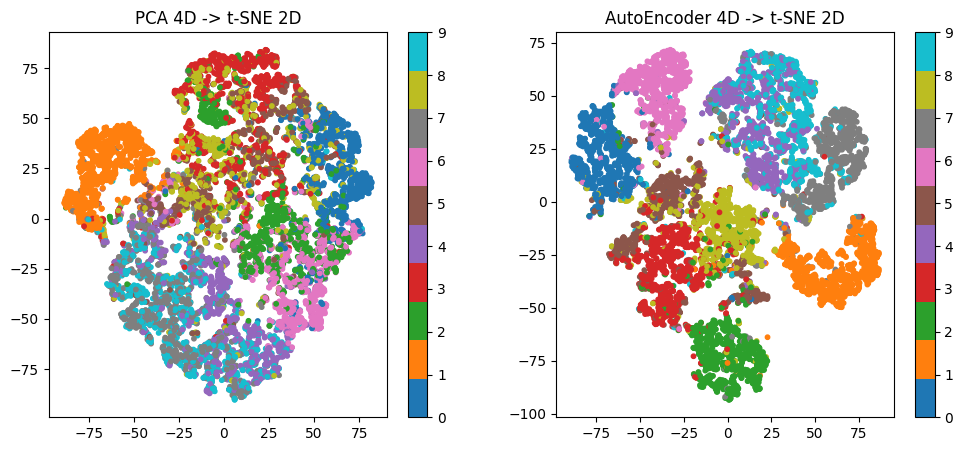

In [ ]:
#Latent vectors for test set
encoder = Model(input_img, encoded)
x_test_ae_latent = encoder.predict(x_test_flat)
x_test_ae_reconstructed = autoencoder.predict(x_test_flat).reshape((-1, 28, 28))

#TSNE Visualization
tsne = TSNE(n_components=2, random_state=42)
x_test_pca_2d = tsne.fit_transform(x_test_pca_latent)
x_test_ae_2d = tsne.fit_transform(x_test_ae_latent)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(x_test_pca_2d[:,0], x_test_pca_2d[:,1], c=y_test, cmap='tab10', s=10)
plt.title("PCA 4D -> t-SNE 2D")
plt.colorbar()
plt.subplot(1,2,2)
plt.scatter(x_test_ae_2d[:,0], x_test_ae_2d[:,1], c=y_test, cmap='tab10', s=10)
plt.title("AutoEncoder 4D -> t-SNE 2D")
plt.colorbar()
plt.show()


In [ ]:
#Reconstruct using PCA and AutoEncoder
x_test_pca_reconstructed_flat = pca.inverse_transform(x_test_pca_latent)
x_test_ae_reconstructed_flat = autoencoder.predict(x_test_flat)

#Compute MSE for PCA
mse_pca = mean_squared_error(x_test_flat, x_test_pca_reconstructed_flat)
print(f"PCA reconstruction MSE: {mse_pca:.6f}")

#Compute MSE for AutoEncoder
mse_ae = mean_squared_error(x_test_flat, x_test_ae_reconstructed_flat)
print(f"AutoEncoder reconstruction MSE: {mse_ae:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
PCA reconstruction MSE: 0.047904
AutoEncoder reconstruction MSE: 0.028705


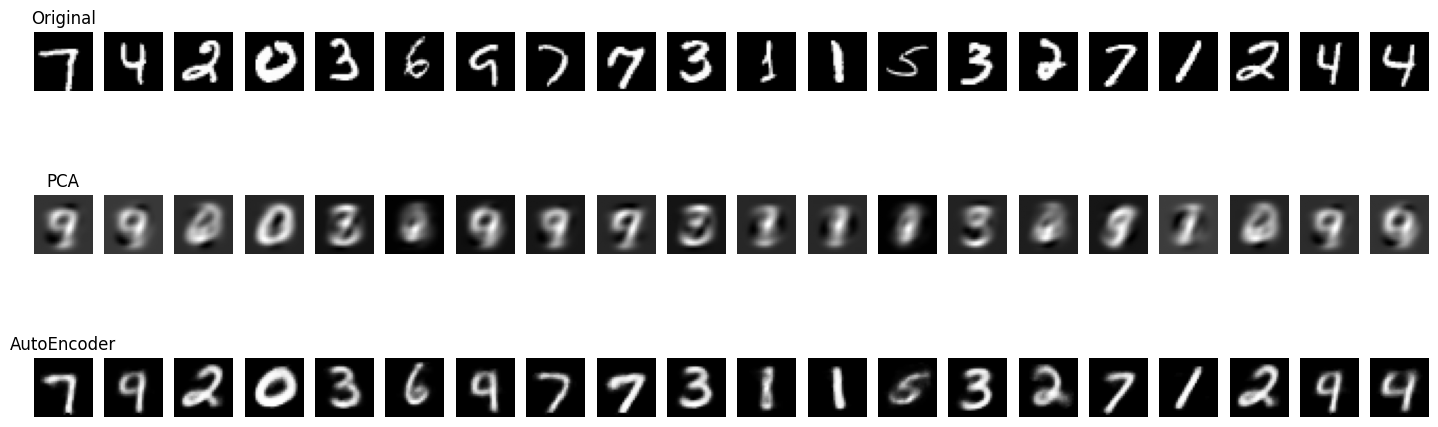

Compression ratio: 196.00:1


In [ ]:
#Show reconstruction for 20 random latent samples
n_samples = 20
indices = np.random.choice(len(x_test_flat), n_samples, replace=False)

plt.figure(figsize=(18,6))
for i, idx in enumerate(indices):
    #Original
    ax = plt.subplot(3, n_samples, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Original")

    #PCA reconstruction
    ax = plt.subplot(3, n_samples, i+1+n_samples)
    plt.imshow(x_test_pca_reconstructed[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("PCA")

    #AutoEncoder reconstruction
    ax = plt.subplot(3, n_samples, i+1+2*n_samples)
    plt.imshow(x_test_ae_reconstructed[idx], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("AutoEncoder")
plt.show()

#Compression ratio
original_size = x_test_flat.shape[1]
latent_size = latent_dim
compression_ratio = original_size / latent_size
print(f"Compression ratio: {compression_ratio:.2f}:1")